In [1]:
import pandas as pd
import json
import Go_tools
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
gobasic = json.load(open("/Users/michael/Data/Reference_data/go-basic.json", "r"))

In [3]:
go_term_matrix = pd.read_csv(
    "/Users/michael/Data/Reference_data/Arabdidopsis_go_matrix_from_tair_gaf.csv",
    index_col=0,
)
go_term_matrix

,GO:0000001,GO:0000009,GO:0000012,GO:0000014,GO:0000023,GO:0000024,GO:0000025,GO:0000026,GO:0000027,GO:0000028,...,GO:2001071,GO:2001080,GO:2001141,GO:2001142,GO:2001143,GO:2001147,GO:2001227,GO:2001280,GO:2001289,GO:2001294
GeneID,,,,,,,,,,,,,,,,,,,,,
AT1G01010,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AT1G01020,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AT1G01030,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AT1G01040,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AT1G01046,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AT5G67600,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AT5G67610,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AT5G67620,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
namespace_columns = [
    "biological_process",
    "molecular_function",
    "cellular_component",
]

graph = gobasic["graphs"][0]
records = []

for go_term in graph.get("nodes", []):
    meta = go_term.get("meta", {})
    basic_property_values = meta.get("basicPropertyValues", [])
    namespace_value = None

    for property_value in basic_property_values:
        if property_value.get("pred", "").endswith("#hasOBONamespace"):
            namespace_value = property_value.get("val")
            break

    go_identifier = go_term.get("id", "")
    go_number = go_identifier.rsplit("/", 1)[-1].replace("GO_", "")
    if not go_number.isdigit():
        continue

    formatted_go_id = f"GO:{int(go_number):07d}"
    record = {column: 0 for column in namespace_columns}
    if namespace_value in record:
        record[namespace_value] = 1
    records.append((formatted_go_id, record))

go_namespace_df = pd.DataFrame(
    [record for _, record in records],
    index=[go_id for go_id, _ in records],
)
go_namespace_df.index.name = "go_id"
go_namespace_df = go_namespace_df.sort_index()
go_namespace_df

,biological_process,molecular_function,cellular_component
go_id,,,
GO:0000001,1,0,0
GO:0000002,1,0,0
GO:0000003,1,0,0
GO:0000004,0,0,0
GO:0000005,0,1,0
...,...,...,...
GO:7770072,0,1,0
GO:7770073,0,1,0
GO:7770074,1,0,0


In [5]:
biological_process_go_terms = go_namespace_df[
    go_namespace_df["biological_process"] == 1
].index
molecular_function_go_terms = go_namespace_df[
    go_namespace_df["molecular_function"] == 1
].index

matrix_biological_process = go_term_matrix.loc[
    :, go_term_matrix.columns.isin(biological_process_go_terms)
]

In [6]:
matrix_molecular_function = go_term_matrix.loc[
    :, go_term_matrix.columns.isin(molecular_function_go_terms)
]
matrix_molecular_function

,GO:0000009,GO:0000014,GO:0000026,GO:0000030,GO:0000033,GO:0000035,GO:0000036,GO:0000049,GO:0000062,GO:0000064,...,GO:1990825,GO:1990837,GO:1990841,GO:1990931,GO:2001066,GO:2001070,GO:2001071,GO:2001080,GO:2001147,GO:2001227
GeneID,,,,,,,,,,,,,,,,,,,,,
AT1G01010,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AT1G01020,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AT1G01030,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AT1G01040,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AT1G01046,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AT5G67600,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AT5G67610,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AT5G67620,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
matrix_biological_process

,GO:0000001,GO:0000012,GO:0000023,GO:0000024,GO:0000025,GO:0000027,GO:0000028,GO:0000038,GO:0000041,GO:0000045,...,GO:2001008,GO:2001009,GO:2001011,GO:2001057,GO:2001141,GO:2001142,GO:2001143,GO:2001280,GO:2001289,GO:2001294
GeneID,,,,,,,,,,,,,,,,,,,,,
AT1G01010,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AT1G01020,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AT1G01030,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AT1G01040,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AT1G01046,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AT5G67600,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AT5G67610,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AT5G67620,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
go_namespace_df.sum(axis=1).max()

np.int64(1)

In [9]:
gene_list = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Junk_data/large_deseq_gene_list_all_plates.csv",
    header=None,
)

In [10]:
gene_list

,0
0,AT1G02930
1,AT1G06680
2,AT1G09340
3,AT1G17080
4,AT1G20340
5,AT1G27290
6,AT1G30250
7,AT1G32060
8,AT1G32080
9,AT1G32470


In [11]:
cleaned_raw_transcriptome = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Generated_data/cleaned_raw_transcriptome.csv",
    index_col=0,
)

In [12]:
background_genes_list = cleaned_raw_transcriptome.columns.tolist()

In [13]:
go_term_names = pd.read_csv(
    "/Users/michael/Data/Reference_data/goterm_names.csv", index_col=0
)
go_term_names

,x
GO:0000001,mitochondrion inheritance
GO:0000006,high-affinity zinc transmembrane transporter a...
GO:0000007,low-affinity zinc ion transmembrane transporte...
GO:0000009,"alpha-1,6-mannosyltransferase activity"
GO:0000010,heptaprenyl diphosphate synthase activity
...,...
GO:7770007,L-arginine conjugated cholate hydrolase activity
GO:7770008,L-histidine conjugated cholate hydrolase activity
GO:7770009,L-tryptophan conjugated cholate hydrolase acti...
GO:7770010,GTPBP3-MTO1 complex


In [14]:
cont_tables_biological_process = Go_tools.generate_contigency_tables(
    go_annotations=matrix_biological_process,
    gene_list=gene_list[0].tolist(),
    use_background_genes=True,
    background_genes=background_genes_list,
)

fishers_results_biological_process = Go_tools.fishers_exact_on_contigency_tables(
    all_go_contigency_tables=cont_tables_biological_process,
    original_GO_term_panda=matrix_biological_process,
)

corrected_fishers_results_biological_process = (
    Go_tools.multi_hypothesis_correct_fishers_exact(fishers_results_biological_process)
)
named_biological_process_results = corrected_fishers_results_biological_process.merge(
    go_term_names, left_index=True, right_index=True, how="left"
)
named_biological_process_results.sort_values("P_value").head(40)

/Users/michael/Git/Bioinformatics_utils/Utilities/Go_tools.py:49: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  - go_subset_distribution_num_genes_annotatated_with_go_term[i]
/Users/michael/Git/Bioinformatics_utils/Utilities/Go_tools.py:51: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  go_subset_distribution_num_genes_annotatated_with_go_term[i],
/Users/michael/Git/Bioinformatics_utils/Utilities/Go_tools.py:55: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by positio

,P_value,x
GO:0009409,0.000019,response to cold
GO:0015979,0.000024,photosynthesis
GO:0009773,0.000174,photosynthetic electron transport in photosyst...
GO:0006412,0.000174,translation
GO:0042631,0.090687,cellular response to water deprivation
GO:0019253,0.090687,reductive pentose-phosphate cycle
GO:0019684,0.100856,"photosynthesis, light reaction"
GO:0015976,0.117419,carbon utilization
GO:0009658,0.484788,chloroplast organization
GO:0032544,0.565086,plastid translation


In [15]:
named_biological_process_results["x"] = named_biological_process_results[
    "x"
].str.capitalize()
named_biological_process_results["Neg Log P Val"] = -1 * np.log10(
    named_biological_process_results["P_value"]
)
named_biological_process_results.sort_values(by="Neg Log P Val", ascending=False).head(
    10
)

,P_value,x,Neg Log P Val
GO:0009409,0.000019,Response to cold,4.710127
GO:0015979,0.000024,Photosynthesis,4.621042
GO:0009773,0.000174,Photosynthetic electron transport in photosyst...,3.759427
GO:0006412,0.000174,Translation,3.759427
GO:0042631,0.090687,Cellular response to water deprivation,1.042454
GO:0019253,0.090687,Reductive pentose-phosphate cycle,1.042454
GO:0019684,0.100856,"Photosynthesis, light reaction",0.996297
GO:0015976,0.117419,Carbon utilization,0.930262
GO:0009658,0.484788,Chloroplast organization,0.314448
GO:0009416,0.565086,Response to light stimulus,0.247885


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Response to cold'),
  Text(0, 1, 'Photosynthesis'),
  Text(0, 2, 'Photosynthetic electron transport in photosystem i'),
  Text(0, 3, 'Translation'),
  Text(0, 4, 'Cellular response to water deprivation'),
  Text(0, 5, 'Reductive pentose-phosphate cycle'),
  Text(0, 6, 'Photosynthesis, light reaction'),
  Text(0, 7, 'Carbon utilization'),
  Text(0, 8, 'Chloroplast organization'),
  Text(0, 9, 'Response to light stimulus')])

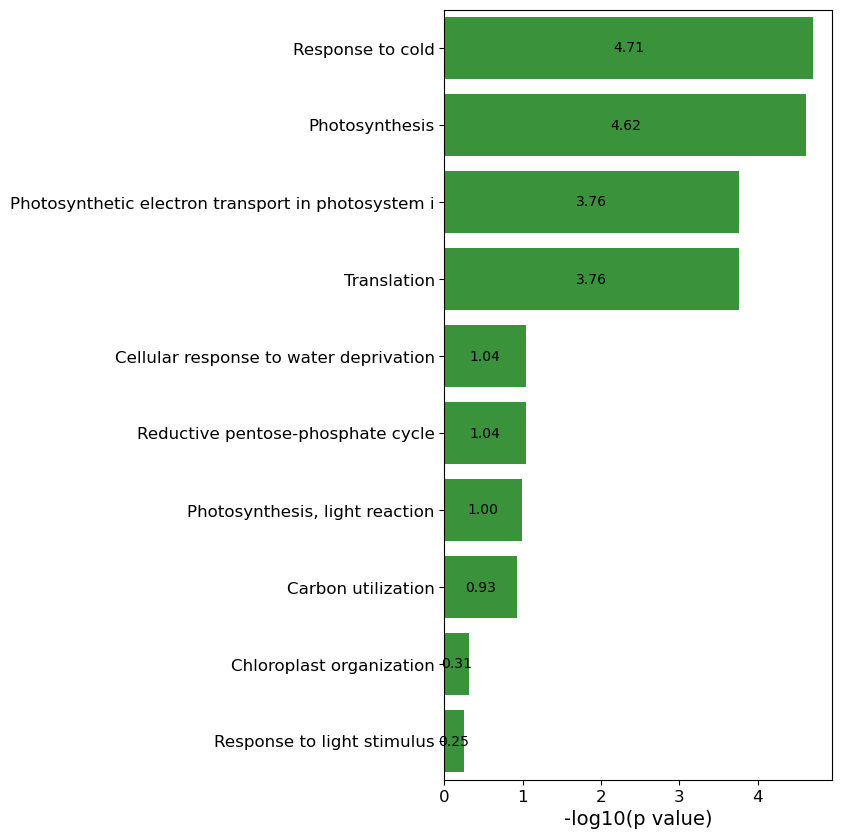

In [16]:
fig, ax = plt.subplots(figsize=(5, 10))
fig.patch.set_facecolor("white")
g = sns.barplot(
    data=named_biological_process_results.sort_values(
        by="Neg Log P Val", ascending=False
    ).head(10),
    x="Neg Log P Val",
    y="x",
    color="tab:green",
)
# plt.ylabel("Euclidian Distance of Coexpressalog from Target Gene", fontsize = 15)
plt.xlabel("-log10(p value)", fontsize=14)
g.set(ylabel=None)
# sns.despine()
g.bar_label(g.containers[0], fmt="%.2f", label_type="center")

g.grid(False)
g.spines["bottom"].set_color("black")
g.spines["left"].set_color("black")
g.spines["top"].set_color("black")
g.spines["right"].set_color("black")
# ax.set_xscale('log')
# plt.xlim((-7,7))
# plt.ylim((0, 1250))
# plt.title("Current Threshold is 31", fontsize = 20)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
# plt.savefig('/data/passala/Plots_for_projects/Coexpressolog_paper_plots/updated_for_v11/go_enrichment_updated.svg')

In [17]:
cont_tables_molecular_function = Go_tools.generate_contigency_tables(
    go_annotations=matrix_molecular_function,
    gene_list=gene_list[0].tolist(),
    use_background_genes=True,
    background_genes=background_genes_list,
)

fishers_results_molecular_function = Go_tools.fishers_exact_on_contigency_tables(
    all_go_contigency_tables=cont_tables_molecular_function,
    original_GO_term_panda=matrix_molecular_function,
)

corrected_fishers_results_molecular_function = (
    Go_tools.multi_hypothesis_correct_fishers_exact(fishers_results_molecular_function)
)
named_molecular_function_results = corrected_fishers_results_molecular_function.merge(
    go_term_names, left_index=True, right_index=True, how="left"
)
named_molecular_function_results.sort_values("P_value").head(40)

/Users/michael/Git/Bioinformatics_utils/Utilities/Go_tools.py:49: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  - go_subset_distribution_num_genes_annotatated_with_go_term[i]
/Users/michael/Git/Bioinformatics_utils/Utilities/Go_tools.py:51: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  go_subset_distribution_num_genes_annotatated_with_go_term[i],
/Users/michael/Git/Bioinformatics_utils/Utilities/Go_tools.py:55: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by positio

,P_value,x
GO:0003729,2.516654e-20,mRNA binding
GO:1901149,2.577201e-03,salicylic acid binding
GO:0008266,1.775715e-02,poly(U) RNA binding
GO:0051920,1.775715e-02,peroxiredoxin activity
GO:0003735,3.809466e-02,structural constituent of ribosome
GO:0004802,9.254210e-01,transketolase activity
GO:0046863,9.254210e-01,"ribulose-1,5-bisphosphate carboxylase/oxygenas..."
GO:0004375,9.254210e-01,glycine dehydrogenase (decarboxylating) activity
GO:0016041,9.855340e-01,glutamate synthase (ferredoxin) activity
GO:0042132,9.855340e-01,"fructose 1,6-bisphosphate 1-phosphatase activity"


In [18]:
named_molecular_function_results["x"] = named_molecular_function_results[
    "x"
].str.capitalize()
named_molecular_function_results["Neg Log P Val"] = -1 * np.log10(
    named_molecular_function_results["P_value"]
)
named_molecular_function_results.sort_values(by="Neg Log P Val", ascending=False).head(
    10
)

,P_value,x,Neg Log P Val
GO:0003729,2.516654e-20,Mrna binding,19.599176
GO:1901149,2.577201e-03,Salicylic acid binding,2.588852
GO:0051920,1.775715e-02,Peroxiredoxin activity,1.750627
GO:0008266,1.775715e-02,Poly(u) rna binding,1.750627
GO:0003735,3.809466e-02,Structural constituent of ribosome,1.419136
GO:0046863,9.254210e-01,"Ribulose-1,5-bisphosphate carboxylase/oxygenas...",0.033661
GO:0004802,9.254210e-01,Transketolase activity,0.033661
GO:0004375,9.254210e-01,Glycine dehydrogenase (decarboxylating) activity,0.033661
GO:2001227,9.855340e-01,Quercitrin binding,0.006328
GO:0016041,9.855340e-01,Glutamate synthase (ferredoxin) activity,0.006328


In [19]:
cellular_component_go_terms = go_namespace_df[
    go_namespace_df["cellular_component"] == 1
].index

matrix_cellular_component = go_term_matrix.loc[
    :, go_term_matrix.columns.isin(cellular_component_go_terms)
]

cont_tables_cellular_component = Go_tools.generate_contigency_tables(
    go_annotations=matrix_cellular_component,
    gene_list=gene_list[0].tolist(),
    use_background_genes=True,
    background_genes=background_genes_list,
)

fishers_results_cellular_component = Go_tools.fishers_exact_on_contigency_tables(
    all_go_contigency_tables=cont_tables_cellular_component,
    original_GO_term_panda=matrix_cellular_component,
)

corrected_fishers_results_cellular_component = (
    Go_tools.multi_hypothesis_correct_fishers_exact(fishers_results_cellular_component)
)
named_cellular_component_results = corrected_fishers_results_cellular_component.merge(
    go_term_names, left_index=True, right_index=True, how="left"
)
named_cellular_component_results.sort_values("P_value").head(40)

/Users/michael/Git/Bioinformatics_utils/Utilities/Go_tools.py:49: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  - go_subset_distribution_num_genes_annotatated_with_go_term[i]
/Users/michael/Git/Bioinformatics_utils/Utilities/Go_tools.py:51: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  go_subset_distribution_num_genes_annotatated_with_go_term[i],
/Users/michael/Git/Bioinformatics_utils/Utilities/Go_tools.py:55: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by positio

,P_value,x
GO:0009941,5.792898e-30,chloroplast envelope
GO:0009579,1.174330e-29,thylakoid
GO:0009570,8.663125e-29,chloroplast stroma
GO:0009507,3.647469e-23,chloroplast
GO:0009535,1.348185e-22,chloroplast thylakoid membrane
GO:0048046,2.244208e-16,apoplast
GO:0010319,1.440382e-13,stromule
GO:0009534,1.619351e-10,chloroplast thylakoid
GO:0031977,8.789610e-07,thylakoid lumen
GO:0010287,1.003375e-06,plastoglobule


In [20]:
named_cellular_component_results["x"] = named_cellular_component_results[
    "x"
].str.capitalize()
named_cellular_component_results["Neg Log P Val"] = -1 * np.log10(
    named_cellular_component_results["P_value"]
)
named_cellular_component_results.sort_values(by="Neg Log P Val", ascending=False).head(
    10
)

,P_value,x,Neg Log P Val
GO:0009941,5.792898e-30,Chloroplast envelope,29.237104
GO:0009579,1.174330e-29,Thylakoid,28.930210
GO:0009570,8.663125e-29,Chloroplast stroma,28.062325
GO:0009507,3.647469e-23,Chloroplast,22.438008
GO:0009535,1.348185e-22,Chloroplast thylakoid membrane,21.870251
GO:0048046,2.244208e-16,Apoplast,15.648937
GO:0010319,1.440382e-13,Stromule,12.841522
GO:0009534,1.619351e-10,Chloroplast thylakoid,9.790659
GO:0031977,8.789610e-07,Thylakoid lumen,6.056030
GO:0010287,1.003375e-06,Plastoglobule,5.998537


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Chloroplast envelope'),
  Text(0, 1, 'Thylakoid'),
  Text(0, 2, 'Chloroplast stroma'),
  Text(0, 3, 'Chloroplast'),
  Text(0, 4, 'Chloroplast thylakoid membrane'),
  Text(0, 5, 'Apoplast'),
  Text(0, 6, 'Stromule'),
  Text(0, 7, 'Chloroplast thylakoid'),
  Text(0, 8, 'Thylakoid lumen'),
  Text(0, 9, 'Plastoglobule')])

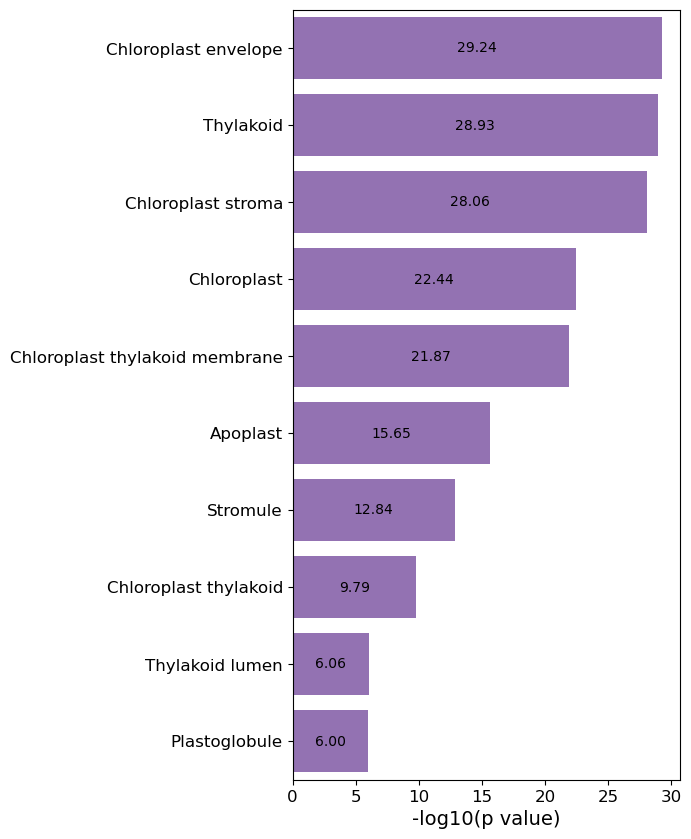

In [21]:
fig, ax = plt.subplots(figsize=(5, 10))
fig.patch.set_facecolor("white")
g = sns.barplot(
    data=named_cellular_component_results.sort_values(
        by="Neg Log P Val", ascending=False
    ).head(10),
    x="Neg Log P Val",
    y="x",
    color="tab:purple",
)
plt.xlabel("-log10(p value)", fontsize=14)
g.set(ylabel=None)
g.bar_label(g.containers[0], fmt="%.2f", label_type="center")

g.grid(False)
g.spines["bottom"].set_color("black")
g.spines["left"].set_color("black")
g.spines["top"].set_color("black")
g.spines["right"].set_color("black")

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Mrna binding'),
  Text(0, 1, 'Salicylic acid binding'),
  Text(0, 2, 'Peroxiredoxin activity'),
  Text(0, 3, 'Poly(u) rna binding'),
  Text(0, 4, 'Structural constituent of ribosome')])

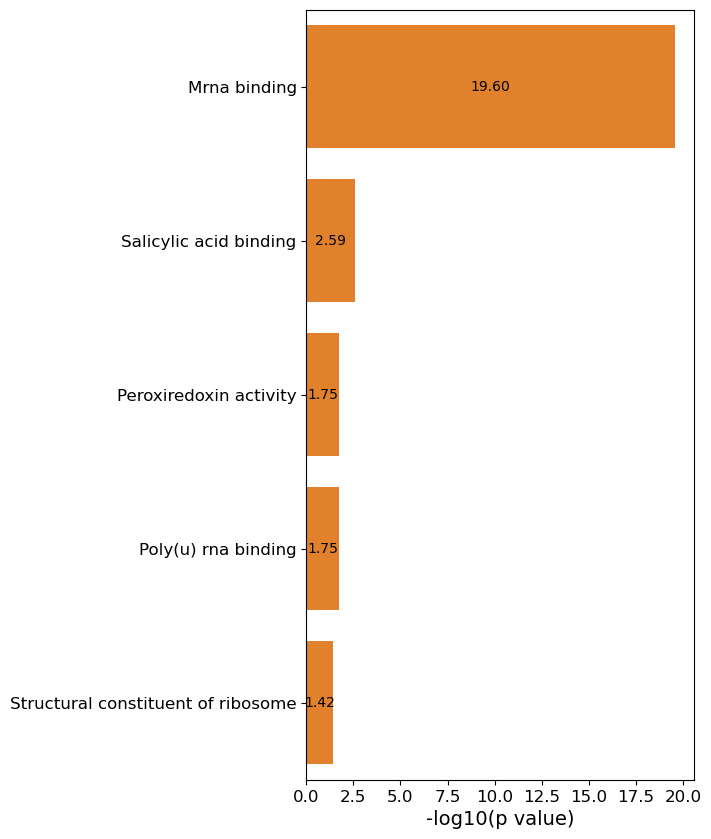

In [23]:
fig, ax = plt.subplots(figsize=(5, 10))
fig.patch.set_facecolor("white")
g = sns.barplot(
    data=named_molecular_function_results.sort_values(
        by="Neg Log P Val", ascending=False
    ).head(5),
    x="Neg Log P Val",
    y="x",
    color="tab:orange",
)
plt.xlabel("-log10(p value)", fontsize=14)
g.set(ylabel=None)
g.bar_label(g.containers[0], fmt="%.2f", label_type="center")

g.grid(False)
g.spines["bottom"].set_color("black")
g.spines["left"].set_color("black")
g.spines["top"].set_color("black")
g.spines["right"].set_color("black")

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)